# Task 1: Top 10 App Categories — Average Rating vs Total Review Count

**Requirements:**
- Grouped bar chart comparing **average rating** and **total review count** for the **top 10 app categories by number of installs**
- Filters applied **before** ranking:
  - Average rating >= 4.0
  - Size >= 10 MB
  - Last Updated in the month of **January** (any year)
- Display rule: this graph should only be shown between **3 PM – 5 PM IST**. Outside that window, the dashboard should not display it. (Implemented in the HTML/dashboard layer, not in the data logic itself — see note at the end of this notebook.)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

pd.set_option('display.max_columns', None)

## 1. Load the data

In [4]:
df = pd.read_csv('googleplaystore.csv')
print(df.shape)
df.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2. Clean the data

The raw columns are messy: `Size` has values like `19M`, `2.8M`, `"Varies with device"`; `Installs` has commas and a trailing `+`; `Last Updated` is a free-text date. We convert each into a proper numeric/datetime type.

In [ ]:
df_clean = df.copy()

# Drop exact duplicate app rows (common issue in this dataset)
df_clean = df_clean.drop_duplicates(subset='App', keep='first')

# --- Size -> numeric MB ---
def parse_size(size):
    if pd.isna(size):
        return np.nan
    size = str(size).strip()
    if size == 'Varies with device' or size == '':
        return np.nan
    if size.endswith('M'):
        return float(size[:-1])
    if size.endswith('k') or size.endswith('K'):
        return float(size[:-1]) / 1024.0  # KB -> MB
    try:
        return float(size)
    except ValueError:
        return np.nan

df_clean['Size_MB'] = df_clean['Size'].apply(parse_size)

# --- Installs -> numeric ---
df_clean['Installs_Num'] = (
    df_clean['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('Free', 'NaN', regex=False)
)
df_clean['Installs_Num'] = pd.to_numeric(df_clean['Installs_Num'], errors='coerce')

# --- Reviews -> numeric ---
df_clean['Reviews_Num'] = pd.to_numeric(df_clean['Reviews'], errors='coerce')

# --- Last Updated -> datetime ---
df_clean['Last_Updated_Date'] = pd.to_datetime(df_clean['Last Updated'], errors='coerce')

# --- Rating -> numeric (already float, but coerce just in case) ---
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')

df_clean[['App','Category','Rating','Reviews_Num','Size_MB','Installs_Num','Last_Updated_Date']].head()

,App,Category,Rating,Reviews_Num,Size_MB,Installs_Num,Last_Updated_Date
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,2018-01-07
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,2018-08-01
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,2018-06-08
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,2018-06-20


## 3. Apply filters

- Average rating >= 4.0
- Size >= 10 MB
- Last Updated month == January

In [ ]:
filtered = df_clean[
    (df_clean['Rating'] >= 4.0) &
    (df_clean['Size_MB'] >= 10) &
    (df_clean['Last_Updated_Date'].dt.month == 1)
].copy()

print(f"Rows after filtering: {len(filtered)} (from {len(df_clean)})")
filtered[['App','Category','Rating','Size_MB','Installs_Num','Last_Updated_Date']].head(10)

Rows after filtering: 121 (from 9660)


,App,Category,Rating,Size_MB,Installs_Num,Last_Updated_Date
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,19.0,10000.0,2018-01-07
33,Easy Origami Ideas,ART_AND_DESIGN,4.2,11.0,100000.0,2018-01-06
44,Popsicle Sticks and Similar DIY Craft Ideas,ART_AND_DESIGN,4.2,12.0,10000.0,2018-01-03
446,Video Caller Id,COMMUNICATION,4.2,17.0,1000000.0,2018-01-24
719,Monster Truck Driver & Racing,EDUCATION,4.4,51.0,1000000.0,2017-01-19
748,Memorado - Brain Games,EDUCATION,4.4,97.0,1000000.0,2017-01-16
917,Nick,ENTERTAINMENT,4.2,25.0,10000000.0,2018-01-24
945,WWE,ENTERTAINMENT,4.5,20.0,10000000.0,2018-01-19
986,Nick Jr. - Shows & Games,ENTERTAINMENT,4.2,35.0,1000000.0,2018-01-23
1215,Om Waleed Sweets,FOOD_AND_DRINK,4.6,23.0,100000.0,2018-01-25


## 4. Aggregate by category and pick the top 10 by installs

In [ ]:
category_stats = filtered.groupby('Category').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews_Num', 'sum'),
    Total_Installs=('Installs_Num', 'sum'),
    App_Count=('App', 'count')
).reset_index()

top10 = category_stats.sort_values('Total_Installs', ascending=False).head(10).reset_index(drop=True)
top10['Avg_Rating'] = top10['Avg_Rating'].round(2)
top10

,Category,Avg_Rating,Total_Reviews,Total_Installs,App_Count
0,SPORTS,4.34,1982017.0,120511000.0,7
1,GAME,4.31,2397589.0,115691000.0,30
2,FAMILY,4.41,2828471.0,96494820.0,38
3,ENTERTAINMENT,4.30,869111.0,21000000.0,3
4,PERSONALIZATION,4.47,155996.0,15060000.0,4
5,PHOTOGRAPHY,4.15,563720.0,10500000.0,2
6,LIFESTYLE,4.38,42809.0,5071000.0,5
7,EDUCATION,4.40,57645.0,2000000.0,2
8,TOOLS,4.20,8010.0,1010000.0,2
9,TRAVEL_AND_LOCAL,4.10,974.0,1001000.0,2


## 5. Grouped bar chart (Plotly — interactive)

Average rating (0–5 scale) and total review count (often in the millions) live on very different scales, so we plot review count on a secondary y-axis while keeping both as bars grouped side by side per category.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=top10['Category'],
    y=top10['Avg_Rating'],
    name='Average Rating',
    marker_color='#4C9AFF',
    yaxis='y1',
    text=top10['Avg_Rating'],
    textposition='outside'
))

fig.add_trace(go.Bar(
    x=top10['Category'],
    y=top10['Total_Reviews'],
    name='Total Review Count',
    marker_color='#FF8C42',
    yaxis='y2',
    text=top10['Total_Reviews'].apply(lambda v: f'{v:,.0f}'),
    textposition='outside'
))

fig.update_layout(
    title='Top 10 App Categories by Installs — Avg Rating vs Total Reviews<br><sup>Filters: Rating ≥ 4.0, Size ≥ 10MB, Last Updated in January</sup>',
    barmode='group',
    xaxis=dict(title='Category', tickangle=-35),
    yaxis=dict(title='Average Rating', range=[0, 5.5], side='left'),
    yaxis2=dict(title='Total Review Count', overlaying='y', side='right', showgrid=False),
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5),
    height=600,
    template='plotly_white',
    margin=dict(t=120, b=120)
)

fig.show()

## 6. Static version (Matplotlib)

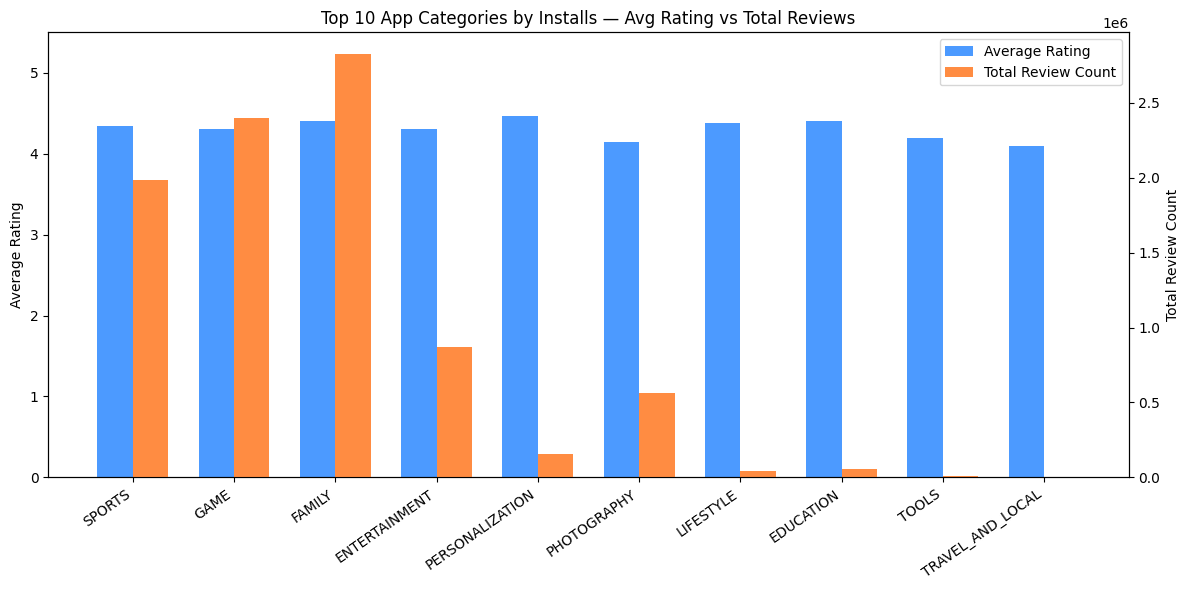

In [ ]:
fig2, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(top10))
width = 0.35

ax1.bar(x - width/2, top10['Avg_Rating'], width, label='Average Rating', color='#4C9AFF')
ax1.set_ylabel('Average Rating')
ax1.set_ylim(0, 5.5)
ax1.set_xticks(x)
ax1.set_xticklabels(top10['Category'], rotation=35, ha='right')

ax2 = ax1.twinx()
ax2.bar(x + width/2, top10['Total_Reviews'], width, label='Total Review Count', color='#FF8C42')
ax2.set_ylabel('Total Review Count')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Top 10 App Categories by Installs — Avg Rating vs Total Reviews')
plt.tight_layout()
plt.savefig('task1_chart.png', dpi=150)
plt.show()

## 7. Export chart data / figure for later embedding

We save the Plotly figure as a standalone `div` (JSON + HTML fragment) so it can be dropped into a combined dashboard HTML page later, once all requested graphs are ready. We are **not** building the final multi-graph HTML page yet, per instructions — that will happen after the remaining charts are built.

In [ ]:
# Save the figure as a reusable HTML fragment (div only, no full <html> page)
fig_html_fragment = pio.to_html(fig, include_plotlyjs=False, full_html=False, div_id='task1_grouped_bar_chart')
with open('task1_fragment.html', 'w') as f:
    f.write(fig_html_fragment)

# Also save the underlying aggregated data as CSV/JSON for reuse
top10.to_csv('task1_top10_categories.csv', index=False)

print('Saved: task1_fragment.html, task1_top10_categories.csv')

Saved: task1_fragment.html, task1_top10_categories.csv
